In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'C:\Infoct_project 1 sample practice\dataset\predictive_maintenance.csv')
print("Dataset loaded!")
print(df.shape)

Dataset loaded!
(10000, 10)


In [3]:
# Recreate all features
np.random.seed(42)
df['Ambient_temperature'] = np.random.normal(loc=295, scale=3, size=len(df))
df['Load_density'] = np.random.uniform(low=0.3, high=1.0, size=len(df))
df["temp_difference"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["power"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]
df["tool_wear_rate"] = df["Tool wear [min]"] / df["Rotational speed [rpm]"]
df["heat_stress_index"] = df["Air temperature [K]"] * df["Tool wear [min]"]
df["wear_per_rotation"] = df["Tool wear [min]"] / df["Rotational speed [rpm]"] * 1000
df["thermal_stress"] = df["temp_difference"] * df["tool_wear_rate"]
df["power_per_temp"] = df["power"] / df["Air temperature [K]"]

# Final 12 features
final_features = ['Air temperature [K]', 'Process temperature [K]','Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
'temp_difference', 'power', 'tool_wear_rate','heat_stress_index', 'wear_per_rotation','thermal_stress', 'power_per_temp']

X = df[final_features]
Y = df['Target']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train LightGBM
model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train_scaled, Y_train)
print("Model trained successfully!")
print(f"Macro F1 Score: {f1_score(Y_test, model.predict(X_test_scaled), average='macro'):.3f}")

[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000602 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2536
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Model trained successfully!
Macro F1 Score: 0.899


In [4]:
# Machine Health Score Function
def calculate_health_score(failure_prob, temp_diff, tool_wear_rate, heat_stress):
    score = 100
    
    # Failure probability penalty (max 50 points)
    score -= failure_prob * 50
    
    # Temperature difference penalty (max 20 points)
    score -= min(abs(temp_diff) * 2, 20)
    
    # Tool wear rate penalty (max 15 points)
    score -= min(tool_wear_rate * 1000, 15)
    
    # Heat stress penalty (max 15 points)
    score -= min(heat_stress / 10000, 15)
    
    return max(0, min(100, score))

# Get health status
def get_health_status(score):
    if score >= 90:
        return "Excellent"
    elif score >= 75:
        return "Good "
    elif score >= 50:
        return "Warning "
    elif score >= 25:
        return "Poor "
    else:
        return "Critical "

print("Health Score System created!")

Health Score System created!


In [5]:
# Maintenance Recommendation Engine
def get_recommendation(health_score, temp_diff, tool_wear_rate, failure_prob):
    recommendations = []
    
    # Temperature check
    if temp_diff > 12:
        recommendations.append("✓ Check cooling system")
    
    # Tool wear check
    if tool_wear_rate > 0.005:
        recommendations.append("✓ Inspect tool wear")
    
    # Failure probability check
    if failure_prob > 0.7:
        recommendations.append("✓ Immediate inspection required!")
    elif failure_prob > 0.4:
        recommendations.append("✓ Schedule maintenance soon")
    
    # Health score check
    if health_score < 25:
        recommendations.append("✓ CRITICAL - Stop machine immediately!")
    elif health_score < 50:
        recommendations.append("✓ Replace worn components")
    
    # If no issues
    if not recommendations:
        recommendations.append("✓ Continue monitoring normally")
    
    return recommendations

print("Maintenance Recommendation Engine created!")

Maintenance Recommendation Engine created!


In [6]:
# Remaining Useful Life Estimation
def estimate_rul(health_score):
    if health_score >= 85:
        rul = "30+ days"
        action = "Next inspection in 30 days"
    elif health_score >= 70:
        rul = "14 days"
        action = "Schedule inspection in 14 days"
    elif health_score >= 50:
        rul = "7 days"
        action = "Urgent inspection in 7 days"
    elif health_score >= 25:
        rul = "2-3 days"
        action = "Immediate attention needed!"
    else:
        rul = "Critical"
        action = "Stop machine - inspect NOW!"
    
    return rul, action

print("RUL Estimation System created!")

RUL Estimation System created!


In [7]:
# Get failure probabilities
failure_proba = model.predict_proba(X_test_scaled)[:, 1]

results = []

for i in range(len(X_test)):
    # Get values
    failure_prob = failure_proba[i]
    temp_diff = X_test.iloc[i]['temp_difference']
    tool_wear_rate = X_test.iloc[i]['tool_wear_rate']
    heat_stress = X_test.iloc[i]['heat_stress_index']
    
    # Calculate health score
    health_score = calculate_health_score(
        failure_prob, temp_diff, tool_wear_rate, heat_stress)
    
    # Get status
    status = get_health_status(health_score)
    
    # Get recommendations
    recommendations = get_recommendation(
        health_score, temp_diff, tool_wear_rate, failure_prob)
    
    # Get RUL
    rul, action = estimate_rul(health_score)
    
    results.append({
        'Machine_ID': f'M{i+101}',
        'Health_Score': round(health_score, 1),
        'Status': status,
        'Failure_Probability': round(failure_prob * 100, 1),
        'RUL': rul,
        'Recommendation': recommendations[0]
    })

results_df = pd.DataFrame(results)
print("=== Machine Health System Results ===")
print(results_df.head(10))

=== Machine Health System Results ===
  Machine_ID  Health_Score    Status  Failure_Probability      RUL  \
0       M101          61.7  Warning                   0.1   7 days   
1       M102          63.5  Warning                   0.0   7 days   
2       M103          57.2  Warning                   7.3   7 days   
3       M104          63.2  Warning                   0.0   7 days   
4       M105          62.9  Warning                   0.1   7 days   
5       M106          61.7  Warning                   0.0   7 days   
6       M107          66.6  Warning                   0.2   7 days   
7       M108          63.7  Warning                   0.0   7 days   
8       M109          62.2  Warning                   0.0   7 days   
9       M110          72.8  Warning                   0.1  14 days   

        Recommendation  
0  ✓ Inspect tool wear  
1  ✓ Inspect tool wear  
2  ✓ Inspect tool wear  
3  ✓ Inspect tool wear  
4  ✓ Inspect tool wear  
5  ✓ Inspect tool wear  
6  ✓ Inspect too

In [8]:
# Show detailed report for specific machines
def print_machine_report(machine_id, health_score, status,  failure_prob, rul, action, recommendations):
    print(f"\n{'='*45}")
    print(f"  MACHINE HEALTH REPORT")
    print(f"{'='*45}")
    print(f"  Machine ID        : {machine_id}")
    print(f"  Health Score      : {health_score}/100")
    print(f"  Status            : {status}")
    print(f"  Failure Prob      : {failure_prob}%")
    print(f"  Remaining Life    : {rul}")
    print(f"  Action Required   : {action}")
    print(f"\n  Recommendations:")
    for rec in recommendations:
        print(f"    {rec}")
    print(f"{'='*45}")

# Print reports for first 3 machines
for i in range(3):
    failure_prob = round(float(model.predict_proba(X_test_scaled)[i, 1]) * 100, 1)
    temp_diff = X_test.iloc[i]['temp_difference']
    tool_wear_rate = X_test.iloc[i]['tool_wear_rate']
    heat_stress = X_test.iloc[i]['heat_stress_index']
    
    health_score = calculate_health_score(
        failure_prob/100, temp_diff, tool_wear_rate, heat_stress)
    status = get_health_status(health_score)
    rul, action = estimate_rul(health_score)
    recommendations = get_recommendation(
        health_score, temp_diff, tool_wear_rate, failure_prob/100)
    
    print_machine_report(
        f"M{i+101}", round(health_score, 1), status,
        failure_prob, rul, action, recommendations)


  MACHINE HEALTH REPORT
  Machine ID        : M101
  Health Score      : 61.8/100
  Status            : Warning 
  Failure Prob      : 0.1%
  Remaining Life    : 7 days
  Action Required   : Urgent inspection in 7 days

  Recommendations:
    ✓ Inspect tool wear

  MACHINE HEALTH REPORT
  Machine ID        : M102
  Health Score      : 63.5/100
  Status            : Warning 
  Failure Prob      : 0.0%
  Remaining Life    : 7 days
  Action Required   : Urgent inspection in 7 days

  Recommendations:
    ✓ Inspect tool wear

  MACHINE HEALTH REPORT
  Machine ID        : M103
  Health Score      : 57.2/100
  Status            : Warning 
  Failure Prob      : 7.3%
  Remaining Life    : 7 days
  Action Required   : Urgent inspection in 7 days

  Recommendations:
    ✓ Inspect tool wear


In [9]:
# Fleet Monitoring Dashboard
print("\n" + "="*60)
print("         FLEET MONITORING DASHBOARD")
print("="*60)
print(f"{'Machine':<10} {'Health':>8} {'Status':<15} {'Failure%':>10} {'RUL':<12}")
print("-"*60)

# Show first 10 machines
for i in range(10):
    failure_prob = round(float(model.predict_proba(X_test_scaled)[i, 1]) * 100, 1)
    temp_diff = X_test.iloc[i]['temp_difference']
    tool_wear_rate = X_test.iloc[i]['tool_wear_rate']
    heat_stress = X_test.iloc[i]['heat_stress_index']
    
    health_score = calculate_health_score(
        failure_prob/100, temp_diff, tool_wear_rate, heat_stress)
    status = get_health_status(health_score)
    rul, action = estimate_rul(health_score)
    
    print(f"M{i+101:<9} {health_score:>8.1f} {status:<15} {failure_prob:>9.1f}% {rul:<12}")

print("="*60)
print(f"\nTotal machines monitored: {len(X_test)}")
print(f"Critical machines: {sum(1 for r in results_df['Status'] if 'Critical' in r)}")
print(f"Warning machines: {sum(1 for r in results_df['Status'] if 'Warning' in r)}")
print(f"Good machines: {sum(1 for r in results_df['Status'] if 'Good' in r)}")


         FLEET MONITORING DASHBOARD
Machine      Health Status            Failure% RUL         
------------------------------------------------------------
M101           61.8 Warning               0.1% 7 days      
M102           63.5 Warning               0.0% 7 days      
M103           57.2 Warning               7.3% 7 days      
M104           63.2 Warning               0.0% 7 days      
M105           62.9 Warning               0.1% 7 days      
M106           61.7 Warning               0.0% 7 days      
M107           66.6 Warning               0.2% 7 days      
M108           63.7 Warning               0.0% 7 days      
M109           62.2 Warning               0.0% 7 days      
M110           72.8 Warning               0.1% 14 days     

Total machines monitored: 2000
Critical machines: 62
Warning machines: 1820
Good machines: 90


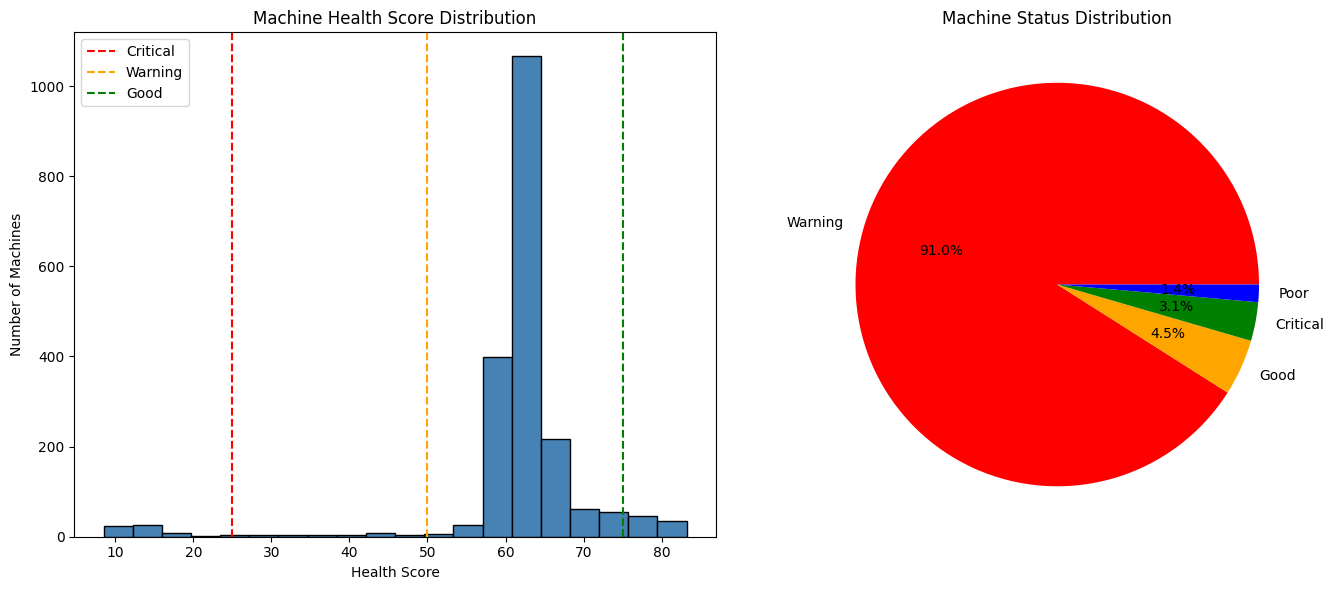

Dashboard visualization saved!


In [10]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 - Health Score Distribution
axes[0].hist(results_df['Health_Score'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Machine Health Score Distribution')
axes[0].set_xlabel('Health Score')
axes[0].set_ylabel('Number of Machines')
axes[0].axvline(x=25, color='red', linestyle='--', label='Critical')
axes[0].axvline(x=50, color='orange', linestyle='--', label='Warning')
axes[0].axvline(x=75, color='green', linestyle='--', label='Good')
axes[0].legend()

# Chart 2 - Status Distribution
status_counts = results_df['Status'].apply(
    lambda x: x.split()[0]).value_counts()
colors = ['red', 'orange', 'green', 'blue']
axes[1].pie(status_counts.values, 
            labels=status_counts.index,
            colors=colors[:len(status_counts)],
            autopct='%1.1f%%')
axes[1].set_title('Machine Status Distribution')

plt.tight_layout()
plt.savefig(
    r'C:\Infoct_project 1 sample practice\results\plots\health_dashboard.png')
plt.show()
print("Dashboard visualization saved!")

In [11]:
# Save results
results_df.to_csv(
    r'C:\Infoct_project 1 sample practice\results\metrics\health_scores.csv',
    index=False)

print("=== Final Summary ===")
print(f"Total machines evaluated: {len(results_df)}")
print(f"Critical machines: {sum(1 for r in results_df['Status'] if 'Critical' in r)}")
print(f"Warning machines: {sum(1 for r in results_df['Status'] if 'Warning' in r)}")
print(f"Good machines: {sum(1 for r in results_df['Status'] if 'Good' in r)}")
print(f"Excellent machines: {sum(1 for r in results_df['Status'] if 'Excellent' in r)}")
print(f"\nResults saved to health_scores.csv!")
print(f"Dashboard saved to health_dashboard.png!")

=== Final Summary ===
Total machines evaluated: 2000
Critical machines: 62
Warning machines: 1820
Good machines: 90
Excellent machines: 0

Results saved to health_scores.csv!
Dashboard saved to health_dashboard.png!
